Before u start coding run this so u can get the DATASET folder with the correct path from github:


In [1]:
!git clone https://github.com/mish841/Alzheimers-Detection-Model---Grey-Hacks-2026.git
%cd Alzheimers-Detection-Model---Grey-Hacks-2026

Cloning into 'Alzheimers-Detection-Model---Grey-Hacks-2026'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 118 (delta 13), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 1.05 MiB | 13.09 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/Alzheimers-Detection-Model---Grey-Hacks-2026


Installing Dependencies & Importing libraries:

In [2]:
# Install dependencies (Colab usually already has these)
!pip install torchvision pillow
!pip install torchvision pillow grad-cam
!pip install torchvision pillow numpy grad-cam gradio

#Imports
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import gradio as gr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 34.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=9d1a11b0cb88be33d34d13a472f992cce9a5ef3441d57ec2c462d677a88d382c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Load the pretrained model: We are using
[ResNet18](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)

In [3]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace classifier for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


Image Processing:

This model excepts 224 x 224 image sizes

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Use our MRI Images which were extracted from a Kaggle dataset to train the dataset a little bit

Link to dataset: [Alzheimer MRI dataset](https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy?utm_source=chatgpt.com)

In [5]:
!rm -rf dataset/train/.ipynb_checkpoints
dataset = datasets.ImageFolder("dataset/train", transform=transform)

train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

Freeze the CNN Layers

In [6]:
# Freeze CNN layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

Training Setup

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

Train the Model

In [8]:
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 12.8577
Epoch 2, Loss: 10.3176
Epoch 3, Loss: 7.7173
Epoch 4, Loss: 6.3336
Epoch 5, Loss: 6.2681


Save the Model and download the model to give to the participants (they will use our TRAINED model, and just fill in the blanks of code. We will create these fill in the blanks ourselves)

In [9]:
torch.save(model.state_dict(), "alz_model.pth")

from google.colab import files
files.download("alz_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Load the Trained Model (Workshop Part 1)

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("alz_model.pth", map_location=device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Upload MRI image

In [11]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving a-10.jpg to a-10.jpg


Load the image

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

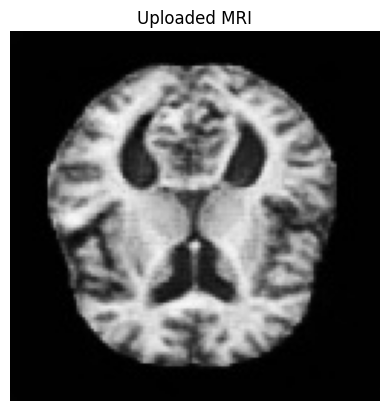

In [12]:
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title("Uploaded MRI")
plt.axis("off")

Run the prediction

In [13]:
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

probs = torch.softmax(output, dim=1)
prediction = torch.argmax(probs, dim=1).item()

classes = ["Healthy", "Alzheimer's"]

print("Prediction:", classes[prediction])
print("Confidence:", probs[0][prediction].item())

Prediction: Healthy
Confidence: 0.9262576699256897


Create a probability bar chart visual

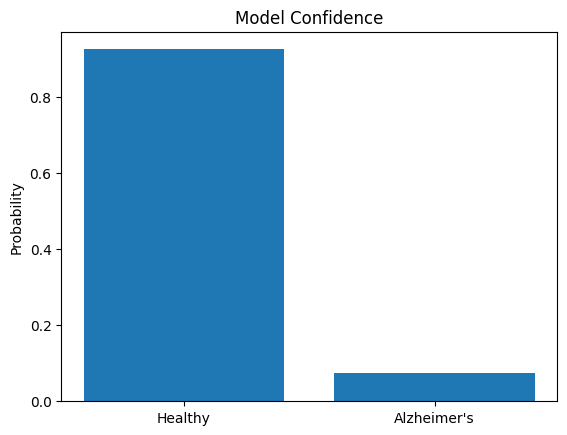

In [14]:
labels = ["Healthy", "Alzheimer's"]
values = probs.cpu().detach().numpy()[0]

plt.bar(labels, values)
plt.title("Model Confidence")
plt.ylabel("Probability")
plt.show()

Add a Grad-CAM Heatmap for more visualization

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

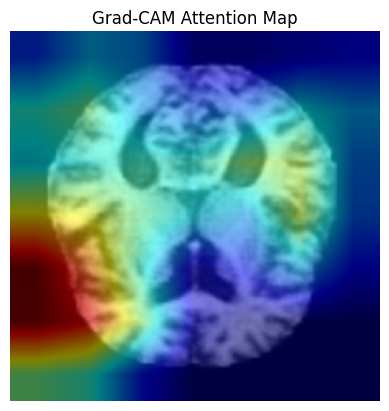

In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = model.layer4[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_img = np.array(image.resize((224,224))) / 255.0

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Attention Map")
plt.axis("off")

Prediction

In [16]:
prediction = torch.argmax(probs, dim=1).item()

classes = ["Healthy", "Alzheimer's"]

print("Prediction:", classes[prediction])
print("Confidence:", probs[0][prediction].item())

Prediction: Healthy
Confidence: 0.9262576699256897


In [ ]:
import gradio as gr

# 1. Force close any existing sessions to fix the 'event loop' error
gr.close_all()

def predict_alzheimers(input_img):
    if input_img is None:
        return None

    # Convert the Gradio input (numpy array) to a PIL Image
    img = Image.fromarray(input_img.astype('uint8')).convert('RGB')

    # Use the 'transform' and 'device' defined in your previous cells
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prediction = model(img_tensor)
        # Apply softmax to get probabilities for the 2 classes
        probs = torch.nn.functional.softmax(prediction[0], dim=0)

    # Based on your logs, the model has 2 output classes
    # Common mapping for binary Alzheimer's models:
    categories = ["Healthy", "Alzheimer's"]

    # Return the results as a dictionary for the Label component
    return {categories[i]: float(probs[i]) for i in range(len(probs))}

# Create the Interface
interface = gr.Interface(
    fn=predict_alzheimers,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=2),
    title="Alzheimer's Detection Model",
    description="Upload an MRI scan to predict if it is Demented or Non-Demented."
)

# Launch with share=True to get a public link
# We use debug=True so we can see any remaining issues in real-time
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d5167ce11457bb65ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
